In [ ]:
# pip install openpyxl

import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
sys.path.append("..")
import matplotlib.dates as mdates
from pathlib import Path


In [2]:
df_w = pd.read_csv("../1-transaction-data/price_series.csv",   index_col="date", parse_dates=True)


In [3]:
target_index = pd.DatetimeIndex(df_w.index)
target_freq = pd.infer_freq(target_index) or "W-MON"

ir = pd.read_excel("interest_rate.xlsx")

date_primary = pd.to_datetime(ir.get("Date"), errors="coerce")
date_fallback = pd.to_datetime(ir.get("ValueDate"), errors="coerce") if "ValueDate" in ir.columns else None
if date_fallback is not None:
    date_col = date_primary.fillna(date_fallback)
else:
    date_col = date_primary

ir = ir.assign(Date=date_col).dropna(subset=["Date"]).sort_values("Date")

ir = ir.set_index("Date")
ir.index = pd.to_datetime(ir.index)

ser = pd.to_numeric(ir["1 Year"], errors="coerce")

ser = ser.groupby(ser.index).mean().sort_index()

interest_rate_series = (
    ser.resample(target_freq).mean()
       .reindex(target_index)
       .ffill()
)

print("interest_rate_series dtype:", interest_rate_series.dtype)
print("First/last:", interest_rate_series.index.min(), "→", interest_rate_series.index.max())
print("NaNs remaining:", interest_rate_series.isna().sum())


interest_rate_series dtype: float64
First/last: 2015-09-06 00:00:00 → 2025-09-28 00:00:00
NaNs remaining: 0


In [4]:
interest_rate_series.to_csv('interest_rate_series.csv', index='date')

In [5]:
interest_rate_series.describe()

count    526.000000
mean       2.864243
std        1.554357
min        0.438936
25%        1.606730
50%        2.568741
75%        4.226400
max        5.669352
Name: 1 Year, dtype: float64

### plot for validation

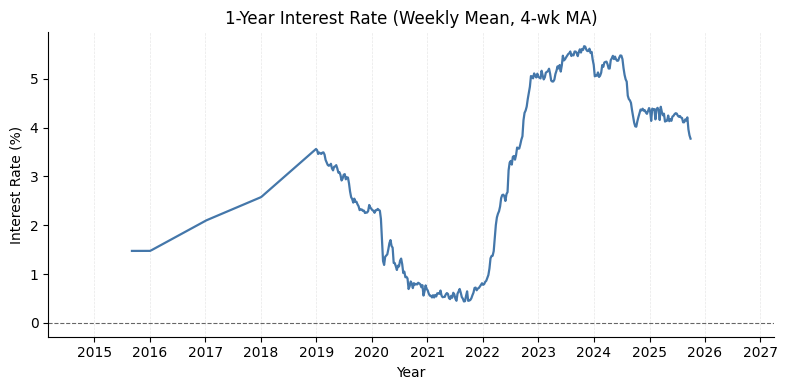

In [6]:
Path("published_images").mkdir(exist_ok=True)

focus_color = "#4477AA"

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    interest_rate_series.index,
    interest_rate_series.values,
    linewidth=1.6,
    color=focus_color
)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)

ax.set_title("1-Year Interest Rate (Weekly Mean, 4-wk MA)")
ax.set_xlabel("Year")
ax.set_ylabel("Interest Rate (%)")
ax.grid(axis="x", alpha=0.3, linestyle="--", linewidth=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.margins(x=0.15)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
fig.savefig("published_images/interest_rate_plot.png", dpi=600, bbox_inches="tight")
plt.show()
